## AlphaEarth Story — Narrative Change Detection Demo

**Purpose**: Main narrative notebook demonstrating AlphaEarth change detection:
cosine similarity analysis, dam destruction detection (Nova Kakhovka, June 2023),
and Austin urban growth visualization.

**Inputs**: `GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL` (2017–2024)
**Outputs**: Interactive geemap visualizations, cosine similarity plots
**GEE auth required**: Yes

**Key parameters** (see `src/config.py`):
- `AE_MAG_THRESHOLD = 0.15` (cosine dissimilarity)
- `AE_SMOOTH_RADIUS = 2`, `AE_SMOOTH_SIGMA = 1`

**Expected runtime**: 5–15 min (interactive; EE tiles load on demand)

**How to run**: Execute cells top-to-bottom. Interactive map cells render in Jupyter Lab/Notebook.
Note: The `geoai` Globe widget cell is commented out — install `geoai` separately to enable it.


# Welcome to Team Alpha's Alpha Earth Exploration Expedition! (TAAEEE!)

***Author: Rushi Bhatt***

Let's start by importing the required packages, you'll need these to follow along.

If it's your first time using the Google Earth Engine API in Python, uncomment `#ee.Authenticate()` down below. 

You'll need to have a valid Google Earth Engine Account and Project, this requires a bit of setup.

(If you are one of our judges and can't get this part setup, please reach out to us directly and I'll be more than happy to help you through this procedure as it is quite involved).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geemap
import ee
#import geoai
#from geoai import Map
import time # All important time
import threading
from datetime import datetime, timedelta # All important timedelta!
import seaborn as sns
from scipy import stats


# Authenticate (this will open a browser window for you to log in)
#ee.Authenticate()

ee.Initialize(project='ardent-fusion-421917')

### This is just some code that creates the world and sets it's spin into motion. 

Running this cell block will let us quickly create visulizations in the future.

In [2]:
class GlobeRotator:
    def __init__(self, map_obj, lon=-121.8036, lat=39.0372, zoom=12, 
                 rotation_speed=0.0001):
        self.map = map_obj
        self.stop_event = threading.Event()
        self.thread = None
        
        # Rotation parameters
        self.lon = lon
        self.lat = lat
        self.current_zoom = zoom
        self.rotation_speed = rotation_speed

    def rotate(self):
        self.stop_event.clear()
        last_fetch_time = time.time()

        while not self.stop_event.is_set():
            # Update longitude and wrap around
            self.lon = (self.lon + self.rotation_speed + 180) % 360 - 180
            
            # Update map center
            self.map.set_center(self.lon, self.lat, zoom=self.current_zoom)
            
            # Periodic tile fetching
            current_time = time.time()
            if current_time - last_fetch_time >= 30:
                # Zoom out and in to refresh tiles
                self.map.set_center(self.lon, self.lat, zoom=max(self.current_zoom - 0.5, 1))
                time.sleep(0.2)
                self.map.set_center(self.lon, self.lat, zoom=self.current_zoom)
                last_fetch_time = current_time
            
            time.sleep(0.1)

    def start(self):
        # Stop existing thread if running
        if self.thread and self.thread.is_alive():
            self.stop()
        
        # Start new rotation thread
        self.stop_event.clear()
        self.thread = threading.Thread(target=self.rotate)
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        if self.thread:
            self.thread.join()

class Viz:
    def __init__(self, center_lon=-121.8036, center_lat=39.0372, zoom=12):
        # Visualization parameters
        self.vis_params = {
            "min": -0.3, 
            "max": 0.3, 
            "bands": ["A01", "A16", "A09"]
        }
        
        self.center_lon = center_lon
        self.center_lat = center_lat
        self.zoom = zoom

        # Map creation
        self.map = geemap.Map()
        self.map.set_center(center_lon, center_lat, zoom)
        
        # Earth Engine collection
        self.collection = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

    def create_split_view(self, left_start_date, right_start_date):
        # Calculate end dates (one year after start)
        left_end_date = (datetime.strptime(left_start_date, "%Y-%m-%d") + timedelta(days=365)).strftime("%Y-%m-%d")
        right_end_date = (datetime.strptime(right_start_date, "%Y-%m-%d") + timedelta(days=365)).strftime("%Y-%m-%d")

        # Filter and create image layers
        left_image = self.collection.filterDate(left_start_date, left_end_date).mosaic()
        right_image = self.collection.filterDate(right_start_date, right_end_date).mosaic()

        # Create layer names
        left_layer_name = f"Satellite Embedding {left_start_date[:4]}-{int(left_start_date[:4])+1}"
        right_layer_name = f"Satellite Embedding {right_start_date[:4]}-{int(right_start_date[:4])+1}"

        # Create tile layers
        left_layer = geemap.ee_tile_layer(left_image, self.vis_params, left_layer_name)
        right_layer = geemap.ee_tile_layer(right_image, self.vis_params, right_layer_name)

        # Create split map view
        self.map.split_map(left_layer, right_layer)

        return self.map

    def start_rotation(self, rotation_speed=0.0001):
        # Create and start globe rotator
        self.rotator = GlobeRotator(
            map_obj=self.map,
            lon=self.center_lon,
            lat=self.center_lat,
            zoom=self.zoom,
            rotation_speed=rotation_speed
        )
        self.rotator.start()
    
    def stop_rotation(self):
        self.rotator.stop()

class VizSimilarity:
    def __init__(self, center_lon=-121.8036, center_lat=39.0372, zoom=12):
        # Visualization parameters
        self.vis_params = {
            "min": 0,
            "max": 0.9,
            "palette": [
                "#0000FF",
                "#FFFFFF",
                "#FF0000",
                "#00000000"
            ]
        }
        
        self.center_lon = center_lon
        self.center_lat = center_lat
        self.zoom = zoom

        # Map creation
        self.map = geemap.Map()
        self.map.set_center(center_lon, center_lat, zoom)
        
        # Earth Engine collection
        self.collection = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

    def cosine_similarity(self, left_start_date="2017-01-01", right_start_date="2024-01-01"):
        # Calculate end dates (one year after start)
        left_end_date = (datetime.strptime(left_start_date, "%Y-%m-%d") + timedelta(days=365)).strftime("%Y-%m-%d")
        right_end_date = (datetime.strptime(right_start_date, "%Y-%m-%d") + timedelta(days=365)).strftime("%Y-%m-%d")

        # Filter embeddings for each year
        filtered_embeddings_1 = self.collection.filterDate(left_start_date, left_end_date)
        filtered_embeddings_2 = self.collection.filterDate(right_start_date, right_end_date)

        # Create mosaic images
        embeddings_image_1 = filtered_embeddings_1.mosaic()
        embeddings_image_2 = filtered_embeddings_2.mosaic()

        # Calculate cosine similarity
        # Select all embedding bands
        bands = embeddings_image_1.bandNames()
        
        # Calculate dot product
        dot_product = embeddings_image_1.multiply(embeddings_image_2).reduce(ee.Reducer.sum())
        
        # Calculate magnitudes
        magnitude1 = embeddings_image_1.pow(2).reduce(ee.Reducer.sum()).sqrt()
        magnitude2 = embeddings_image_2.pow(2).reduce(ee.Reducer.sum()).sqrt()
        
        # Cosine similarity
        similarity_image = dot_product.divide(magnitude1.multiply(magnitude2))

        # Add layer to map
        layer_name = f'Cosine Similarity ({left_start_date[:4]} vs {right_start_date[:4]})'
        similarity_layer = geemap.ee_tile_layer(
            similarity_image, 
            self.vis_params, 
            layer_name
        )
        self.map.add_layer(similarity_layer)

        return {
            'map': self.map,
            'similarity_image': similarity_image,
        }

    def start_rotation(self, rotation_speed=0.0001):
        # Create and start globe rotator
        self.rotator = GlobeRotator(
            map_obj=self.map,
            lon=self.center_lon,
            lat=self.center_lat,
            zoom=self.zoom,
            rotation_speed=rotation_speed
        )
        self.rotator.start()
    
    def stop_rotation(self):
        self.rotator.stop()

    def cosine_similarity_chart(self, square_size=100, left_start_date="2017-01-01", right_start_date="2024-01-01"):
        """
        Create a chart showing log-transformed cosine similarity over years within a specified square geometry.

        Args:
            square_size (int): Size of the square geometry in kilometers
            left_start_date (str): Start date for the first time period
            right_start_date (str): Start date for the last time period

        Returns:
            matplotlib figure with cosine similarity chart
        """
        # Create a square geometry centered on the specified coordinates
        center_point = ee.Geometry.Point([self.center_lon, self.center_lat])
        
        # Convert square size from km to degrees (approximate)
        # Note: This is a rough approximation and may vary slightly at different latitudes
        deg_conversion = square_size / 111  # 1 degree is approximately 111 km
        
        # Create a square geometry
        square_geometry = center_point.buffer(deg_conversion/2).bounds()

        # Parse start and end years
        start_year = int(left_start_date[:4])
        end_year = int(right_start_date[:4])

        # Prepare lists to store results
        years = []
        log_similarities = []

        # Calculate cosine similarities between consecutive years
        for year in range(start_year, end_year):
            left_date = f"{year}-01-01"
            right_date = f"{year+1}-01-01"

            # Filter embeddings for each year
            filtered_embeddings_1 = self.collection.filterDate(left_date, right_date).filterBounds(square_geometry)
            filtered_embeddings_2 = self.collection.filterDate(right_date, f"{year+2}-01-01").filterBounds(square_geometry)

            # Create mosaic images
            embeddings_image_1 = filtered_embeddings_1.mosaic()
            embeddings_image_2 = filtered_embeddings_2.mosaic()

            # Calculate cosine similarity
            dot_product = embeddings_image_1.multiply(embeddings_image_2).reduce(ee.Reducer.sum())
            magnitude1 = embeddings_image_1.pow(2).reduce(ee.Reducer.sum()).sqrt()
            magnitude2 = embeddings_image_2.pow(2).reduce(ee.Reducer.sum()).sqrt()
            
            similarity_image = dot_product.divide(magnitude1.multiply(magnitude2))

            # Manually apply log transform and calculate mean
            # Add a small epsilon to avoid log(0)
            epsilon = 1 + 1e-10
            log_similarity_image = similarity_image.add(epsilon).log()

            # Calculate average of log-transformed similarity
            avg_log_similarity = log_similarity_image.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=square_geometry,
                scale=30,
                maxPixels=1e9
            )

            # Get the scalar value
            similarity_value = avg_log_similarity.get('sum').getInfo()
            
            years.append(year)
            log_similarities.append(similarity_value)

        # Create the plot
        plt.figure(figsize=(10, 6))
        plt.plot(years, log_similarities, marker='o')
        plt.title(f'Log-Transformed Cosine Similarity\n{square_size}km Square at ({self.center_lon}, {self.center_lat})')
        plt.xlabel('Year')
        plt.ylabel('Log-Transformed Cosine Similarity')
        plt.grid(True)

        return plt.gcf()  # Return the figure



In [3]:
#m = Map(projection="globe", sidebar_visible=True)
#m.add_basemap("USGS.Imagery")
#m.add_alphaearth_gui()
#m

## While human societies have undergone significant transformations between 2017 and 2024, the fundamental physical characteristics of our planet remain remarkably stable. Planetary changes typically occur over geological timescales—spanning millions of years—with most observable alterations happening incrementally and often imperceptibly to the human eye. With a keen eye, you may still notice changes!

In [4]:
# Create Visualization
alpha_viz = Viz(center_lon=0, center_lat=0, zoom=3)

# Create split view
map_view = alpha_viz.create_split_view(
    left_start_date="2017-01-01", 
    right_start_date="2024-01-01"
)

# Start rotation but timeout after a minute
alpha_viz.start_rotation(rotation_speed=0.9)
threading.Timer(60, alpha_viz.stop_rotation).start()
alpha_viz.map

Map(center=[0, 0.9000000000000057], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

*Right, right... changes... I just see color!.*

*Care to explain what I'm looking at here?*

AlphaEarth is a model that creates a 10x10 meter resolution digital replica of Earth's surface by integrating multiple types of geographic and environmental data, including optical satellite imagery, radar scans, LiDAR-based elevation models, climate readings, etc. Currently, AlphaEarth has data available from 2017 - 2024. Note that input data sources have varying spatial and temporal resolutions.

The key innovation of AlphaEarth lies in its ability to compress these complex, multi-source datasets into a single, computer-readable 64-dimensional "embedding". This means the system transforms vast amounts of raw geographic information into a compact, analyzable format that computer systems can quickly process and interpret. Being limited by human dimensions, what you're seeing here is a false color image of just *three* of those 64 dimensions.

Because we have some people from TACC here, I'll make a computing analogy. Think of this 64-dim embedding as a similarity-preserving hashing algorithm, like Locality-Sensitive Hashing (LSH). Unlike a cryptographic hashing algorithm like SHA256, which aims to create unique, non-colliding hashes, a similarity-preserving algorithm intentionally creates collisions for similar items.

And like a hash, the values of our 64-dim vector have no 'real-world' meaning. It is simply a signature of the data that it's been trained on. This is different to something like a RGB vector <R, G, B>, where each value corresponds to the signature of the visible light spectrum. <A00, A01, A02, ... A63> cannot be used to tell *what* is at a given point or location, but it's simply a signature of remote sensing data sampled at that vector location.

The usefulness of AlphaEarth is still bound to the usefulness of the data it's been trained on. You can still see remote sensing artifacts over the dataset if you know what you're looking for. "AI" can't magically "sense" things on Earth that it's training datasets don't know about. But that's not what the purpose of this model is.

*So what is it then?*

Since the launch of the Sputnik 1 satellite in 1957, humanity has launched nearly a thousand observational satellites to help us understand our globe. Lacking an efficient system, we've hoarded this data and dreamed of one day being able to process and tell stories of what is happening in the petabytes of floating point values sitting in storage drives in datacenters just like TACCs. With AlphaEarth, this dream is beginning to become a reality. Our attempt will be to now use and extend some tooling around this model in Python as not much exists online yet to help make analysis easier and to hopefully tell *you* a story along the way.

## Let's start our journey in Eritrea. Hominid remains found in Eritrea have been dated to 1 million years old and anthropological research indicates that the area may contain significant records related to the evolution of humans. How has this place evolved in this last eight years?

In [5]:
alpha_viz = Viz(center_lon=35.0, center_lat=18.0, zoom=10)

map_view = alpha_viz.create_split_view(
    left_start_date="2017-01-01",
    right_start_date="2024-01-01"
)

alpha_viz.map

Map(center=[18.0, 35.0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

### That change is still pretty hard to see... let's make a different kind of map!

In [6]:
alpha_viz = VizSimilarity(center_lon=35.0, center_lat=18.0, zoom=10)

# Create split view and start rotation
map_view = alpha_viz.cosine_similarity(
    left_start_date="2017-01-01",
    right_start_date="2024-01-01"
)

#alpha_viz.start_rotation(rotation_speed=0.001)
#threading.Timer(60, alpha_viz.stop_rotation).start()
alpha_viz.map

Map(center=[18.0, 35.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

*Wow, how'd you do that??*

Remember how every 10x10 meter grid has a 64-dim vector? We can take the angle between the two vectors, called cosine similarity, to see how each 10 x 10 meter grid has changed between two time periods. This is the power of vector mathematics!

*Those giant circles, are they building UFO landing pads?*

No, unfortunately, that is just a conspiracy theory. Those giant red circles are pivot irrigation circles. They are highly efficient in terms of water use compared to traditional irrigation.

A visualization like this makes it easy to track agricultural expansion and land use changes. Did the irrigation circles already exist before? Are we for some reason seeing a change in *some* geographical regions but not others?

These visualizations allow the formation of such questions to now be explored in a more detailed scientific study. 

Remember, we only know that *something* changed here. We can compare images to see if that change was it's existence, but if not, the change may be attributable to crop rotation, crop disease, ... 

## Next, let's go to Nova Kakhovka Dam!

The coordinates are centered on the location of the former Nova Kakhovka Dam, which was destroyed on June 6, 2023, during the ongoing conflict in Ukraine. Notice a difference?

In [7]:
# Coordinates for Nova Kakhovka Dam region
dam_viz = Viz(center_lon=33.37, center_lat=46.78, zoom=11)

result = dam_viz.create_split_view(
    left_start_date="2017-01-01",
    right_start_date="2024-01-01"
)

# Access the map
dam_viz.map


Map(center=[46.78, 33.37], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

You may see differences in the map above and wonder, why don't they show up as red in the map below?

Remember, the map above is a false-color image of only *3* of the *64* dimensions. This is why the cosine similarity map is so powerful, it's a way to visualizing change in all 64-dimensions in as a single value (that we then visualize in <R, G, B>).

In [8]:
# Coordinates for Nova Kakhovka Dam region
alpha_viz = VizSimilarity(center_lon=33.37, center_lat=46.78, zoom=11)

result = alpha_viz.cosine_similarity(
    left_start_date="2017-01-01",
    right_start_date="2024-01-01"
)

# Access the map
alpha_viz.map

Map(center=[46.78, 33.37], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

Not only can we tell where change happened here, but also the relative rate at which it occurred. There's a method in our visualization toolbox called `.cosine_similarity_chart()`. 

what this does is it takes the center lon/lat of the map, creates a 100km square around that point, calculates the YoY Cosine Similarity in that region, applies a log transform on those values, and then gets the sum of those values.

*To reduce computational needs, we actually calculates the mean of cosine similarity of each 30 meter region first and then log transform those values*

Why log transform? To help deduces the impact of extremely high or low pixel values due to the distribution of our data.

### I have an error in x-axis here, off by one errors are haunting! *sigh* All years should have +1 added to them!

But the dam was destroyed on June 6, 2023. Which is exactly when we see the similarity drop!

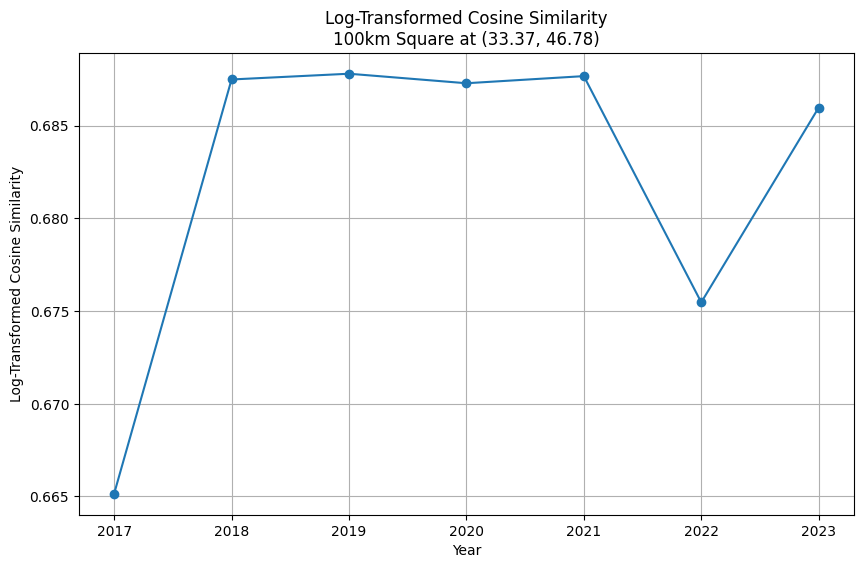

In [9]:
fig = alpha_viz.cosine_similarity_chart()

plt.show()

## Remember how we previously mentioned that each 10 x 10 meter grid is assigned a "hash" like vector that we can compute similarity of?

Well, if you know the signature of something you're looking for, you can label it, and then search for other instances of that signature.

This method is currently being used in Brazil to help search for and classify sub-biomes, a task that can be very challenging to do by hand.

Let's apply this at a very small scale and look for some ponds!

In [10]:
import ee
import geemap

m = geemap.Map(
    center=[45.21, -453.23],
    zoom=16,
    basemap='SATELLITE'
)
m


Map(center=[45.21, -453.23], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

And before you ask, no, that isn't a impact crater from the The Younger Dryas Impact.

We define a search radius around all labeled points in which to search for matching objects, you can set this above! That circle is the search radius and the similarity results within.

In [11]:
# Choose the scale of your object. If your subject is 30 m in footprint, choose a value around 30!
# We're going to look for some ponds so 20 m is a good value.

scale = 20
threshold = 0.90
radius = 10000

## At the very end, let's go somewhere our judges would like to go!

In [12]:
center_lon = -97.7431
center_lat = 30.2672
zoom = 11

In [13]:
alpha_viz = Viz(center_lon=center_lon, center_lat=center_lat, zoom=zoom)

map_view = alpha_viz.create_split_view(
    left_start_date="2017-01-01",
    right_start_date="2024-01-01"
)

alpha_viz.map

Map(center=[30.2672, -97.7431], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'z…

In [14]:
alpha_viz = VizSimilarity(center_lon=center_lon, center_lat=center_lat, zoom=zoom)

result = alpha_viz.cosine_similarity(
    left_start_date="2017-01-01",
    right_start_date="2024-01-01"
)

alpha_viz.map

Map(center=[30.2672, -97.7431], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…